## Split data into training and test sets

This notebook prepares the training and test datasets for further analysis and modeling.

Main steps:

1. Load `telco_customers_clean` and validate:

   - dimensions,
   - data types.

2. Analyze the target column `churn`:

   - confirm the SQL insight that the target distribution is imbalanced,
   - decide whether stratified sampling should be used during the train-test split.

3. Split the data into training and test sets:

   - use stratification to preserve the target distribution,
   - inspect the `churn` distribution after the split.

4. Save the training and test sets to CSV files.


In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from telco_churn.config import (
    TARGET_COLUMN,
    TEST_SIZE,
    RANDOM_STATE,
)
from telco_churn.data_preparation import (
    save_df_to_csv,
    train_test_data_split,
)
from telco_churn.paths import(
    TELCO_CUSTOMERS_CLEAN_PATH,
    TELCO_CUSTOMERS_TEST_PATH,
    TELCO_CUSTOMERS_TRAIN_PATH,
    TRAIN_TEST_SPLIT_FIGURES_DIR,
)
from telco_churn.plots import (
    add_bar_labels,
    save_plot,
)

## 1. Load `telco_customers_clean`

In [2]:
df_clean = pd.read_csv(TELCO_CUSTOMERS_CLEAN_PATH)

In [3]:
df_clean.shape

(7043, 21)

In [4]:
df_clean.dtypes

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object

## 2. Analyze the target column `churn`

In [5]:
churn_distribution_count = df_clean[TARGET_COLUMN].value_counts()
total_count = churn_distribution_count.sum()
churn_distribution_pct = (churn_distribution_count / total_count * 100).round(2)

churn_distribution_summary = pd.concat(
    [churn_distribution_count, churn_distribution_pct],
    axis=1,
    keys=['count', 'percentage'],
)

churn_distribution_summary

,count,percentage
churn,,
No,5174,73.46
Yes,1869,26.54


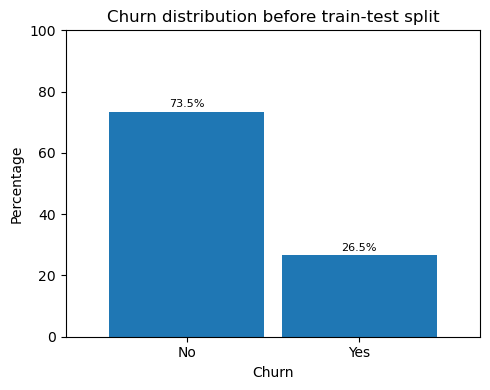

In [9]:
churn_bar_plot = churn_distribution_summary['percentage'].plot(
    kind='bar',
    width=0.9,
    rot=0,
    figsize=(5, 4),
)
add_bar_labels(axes=churn_bar_plot)
churn_bar_plot.set_ylim(0, 100)
churn_bar_plot.set_title('Churn distribution before train-test split')
churn_bar_plot.set_xlabel('Churn')
churn_bar_plot.set_ylabel('Percentage')
plt.tight_layout()
save_plot(
    path=TRAIN_TEST_SPLIT_FIGURES_DIR,
    file_name='churn_distribution_before_train_test_split',
)
plt.show()

### Summary

The `churn` target distribution is imbalanced. Customers who churned represent a much smaller group than customers who did not churn.

Because of that, I will use a stratified train-test split to preserve similar churn proportions in both the training and test datasets.

## 3. Split the data into training and test sets

In [10]:
df_train, df_test = train_test_data_split(
    df=df_clean,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify_column=TARGET_COLUMN,
)

In [11]:
# Validate whether the train-test proportions match the configured split.
split_size_validation = pd.DataFrame(
    {
        'dataset': ['df_train', 'df_test'],
        'rows': [
            df_train.shape[0],
            df_test.shape[0],
        ],
        'percentage': [
            round(df_train.shape[0] / df_clean.shape[0] * 100, 1),
            round(df_test.shape[0] / df_clean.shape[0] * 100, 1),
        ],
    }
).set_index('dataset')

split_size_validation

,rows,percentage
dataset,,
df_train,5634,80.0
df_test,1409,20.0


In [12]:
# Validate whether the churn distributions after the stratified train-test
# split match the distribution before the split.
churn_train_distribution = (
    df_train[TARGET_COLUMN]
    .value_counts(normalize=True)
    * 100
).round(2)

churn_test_distribution = (
    df_test[TARGET_COLUMN]
    .value_counts(normalize=True) 
    * 100
).round(2)

churn_distribution_validation = pd.concat(
    [churn_distribution_pct, churn_train_distribution, churn_test_distribution],
    axis=1,
    keys=['df_clean', 'df_train', 'df_test'],
)

churn_distribution_validation

,df_clean,df_train,df_test
churn,,,
No,73.46,73.46,73.46
Yes,26.54,26.54,26.54


### Summary

The split size validation confirms that the dataset was split into approximately 80% training data and 20% test data. 

The target distribution validation confirms that stratification preserved similar `churn` proportions in both datasets.

## 4. Save the training and test sets to CSV files.

In [13]:
train_set_path = save_df_to_csv(
    df=df_train,
    path=TELCO_CUSTOMERS_TRAIN_PATH
)

In [14]:
test_set_path = save_df_to_csv(
    df=df_test,
    path=TELCO_CUSTOMERS_TEST_PATH
)

## Summary

The dataset was split into training and test sets using a stratified train-test split.

Key outputs from this notebook:
- Bar plot with churn distribution saved to: `reports/figures/train_test_split/churn_pct_distribution.png`
- Train set saved to: `data/processed/telco_customers_train.csv`
- Test set saved to: `data/processed/telco_customers_test.csv`